<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/02-regression/Used-Cars-Prediction/Used_Cars_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used Cars Prediction

## Importing libraries

In [47]:
!pip install category_encoders

In [116]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:2f}'.format)

## Loading the dataset

In [49]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "vehicles.csv"

# Load the latest version
used_cars = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "austinreese/craigslist-carstrucks-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [50]:
df = used_cars.copy()

In [51]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [52]:
df.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.000000,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.000000,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.000000,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.000000,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.000000,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


## EDA

In [53]:
print(f"Number of rows in dataset: {df.shape[0]}")
print(f"Number of cols in dataset: {df.shape[1]}")

Number of rows in dataset: 426880
Number of cols in dataset: 26


In [54]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

Columns to remove: id, url, region_url, title_status, VIN, image_url, description, county, posting_date

---



In [55]:
df['drive']

,drive
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
426875,fwd
426876,fwd
426877,NaN
426878,fwd


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [57]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


In [58]:
print(f"Total number of NaN values is: {df.isnull().sum().sum()}")

Total number of NaN values is: 1655336


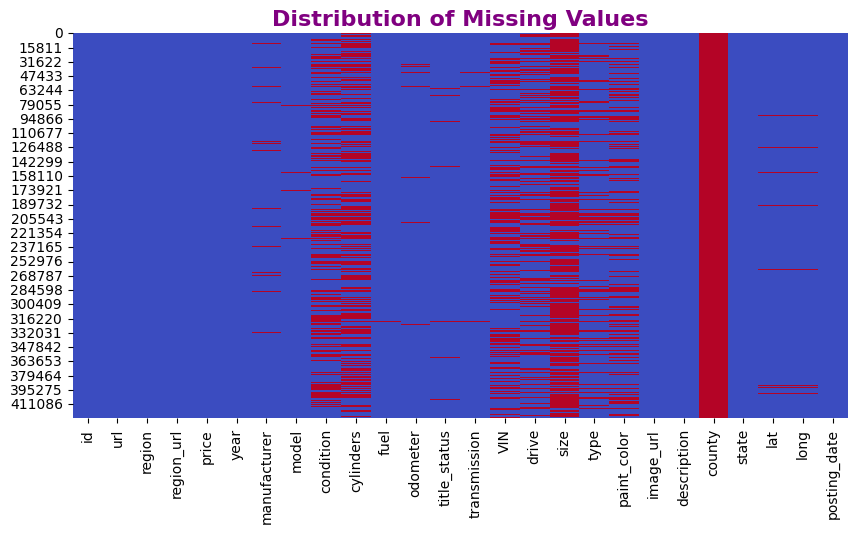

In [59]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), annot=False, cmap='coolwarm', cbar=False)
plt.title("Distribution of Missing Values", fontsize=16, fontweight='bold', color='purple')
plt.show()

In [60]:
df.describe()

,id,price,year,odometer,county,lat,long
count,426880.000000,426880.000000,425675.000000,422480.000000,0.000000,420331.000000,420331.000000
mean,7311486634.224333,75199.033187,2011.235191,98043.331443,NaN,38.493940,-94.748599
std,4473170.412559,12182282.173604,9.452120,213881.500798,NaN,5.841533,18.365462
min,7207408119.000000,0.000000,1900.000000,0.000000,NaN,-84.122245,-159.827728
25%,7308143339.250000,5900.000000,2008.000000,37704.000000,NaN,34.601900,-111.939847
50%,7312620821.000000,13950.000000,2013.000000,85548.000000,NaN,39.150100,-88.432600
75%,7315253543.500000,26485.750000,2017.000000,133542.500000,NaN,42.398900,-80.832039
max,7317101084.000000,3736928711.000000,2022.000000,10000000.000000,NaN,82.390818,173.885502


In [61]:
corr_matrix = df.select_dtypes(include=['number']).corr()
corr_matrix

,id,price,year,odometer,county,lat,long
id,1.000000,-0.002779,-0.059040,0.010721,NaN,-0.069388,-0.121864
price,-0.002779,1.000000,-0.004925,0.010032,NaN,0.000357,-0.000408
year,-0.059040,-0.004925,1.000000,-0.157215,NaN,-0.014677,-0.001410
odometer,0.010721,0.010032,-0.157215,1.000000,NaN,-0.001459,0.009807
county,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,-0.069388,0.000357,-0.014677,-0.001459,NaN,1.000000,-0.128088
long,-0.121864,-0.000408,-0.001410,0.009807,NaN,-0.128088,1.000000


In [62]:
corr_matrix['price'].sort_values(ascending=False)

,price
price,1.000000
odometer,0.010032
lat,0.000357
long,-0.000408
id,-0.002779
year,-0.004925
county,NaN


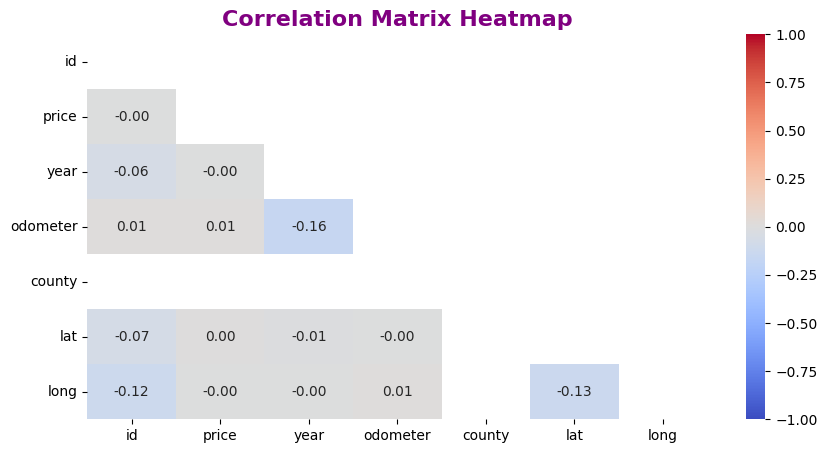

In [63]:
plt.figure(figsize=(10, 5))
mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix Heatmap", fontsize=16, fontweight='bold', color='purple')
plt.show()

In [64]:
def plot_hist_kde_box(column_name, data=df):
  plt.figure(figsize=(15, 5))

  # Plot Histogram
  plt.subplot(1, 3, 1)
  sns.histplot(data[column_name], kde=True, color='b')
  plt.title(f"{column_name.capitalize()} Distribution", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Frequency", fontsize=14)

  # Plot KDE
  plt.subplot(1, 3, 2)
  sns.kdeplot(data=data, x=column_name, fill=True, color='r')
  plt.title(f"Kernel Density Estimate of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Density", fontsize=14)
  plt.xlim(data[column_name].min(), data[column_name].max())

  # Plot Box Plot
  plt.subplot(1, 3, 3)
  sns.boxplot(y=data[column_name], color='g')
  plt.title(f"Box Plot of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)

  plt.tight_layout()
  plt.show()

In [65]:
lower = df['price'].quantile(.10)
upper = df['price'].quantile(.99)
filter_df = df[(df['price'] > lower) & (df['price'] < upper)]

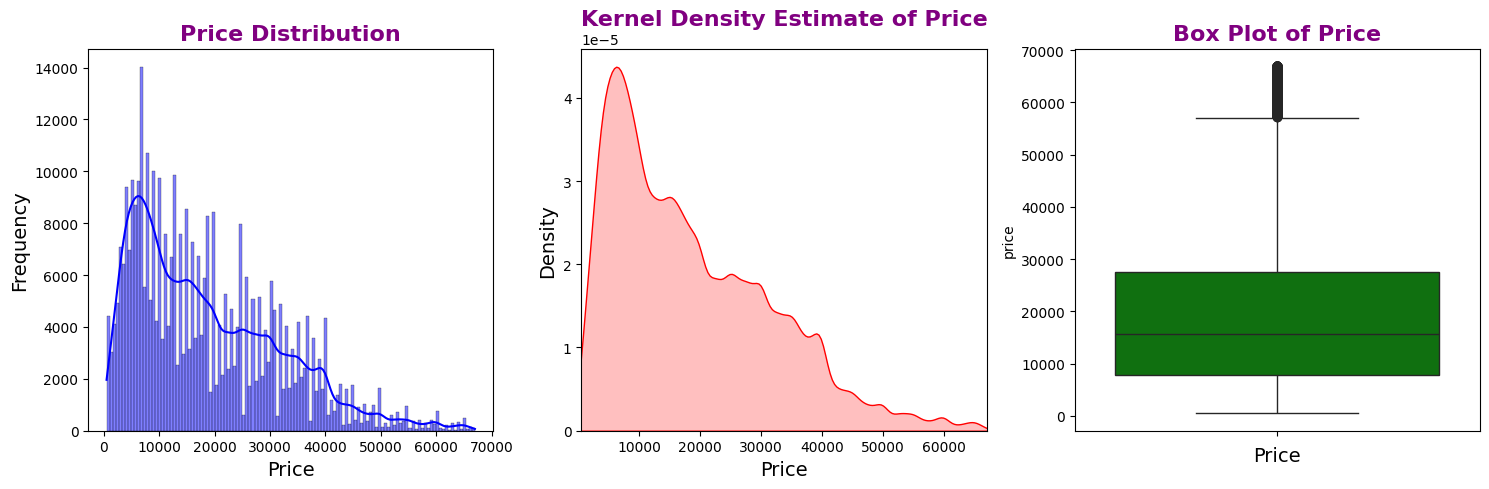

In [66]:
plot_hist_kde_box('price', filter_df)

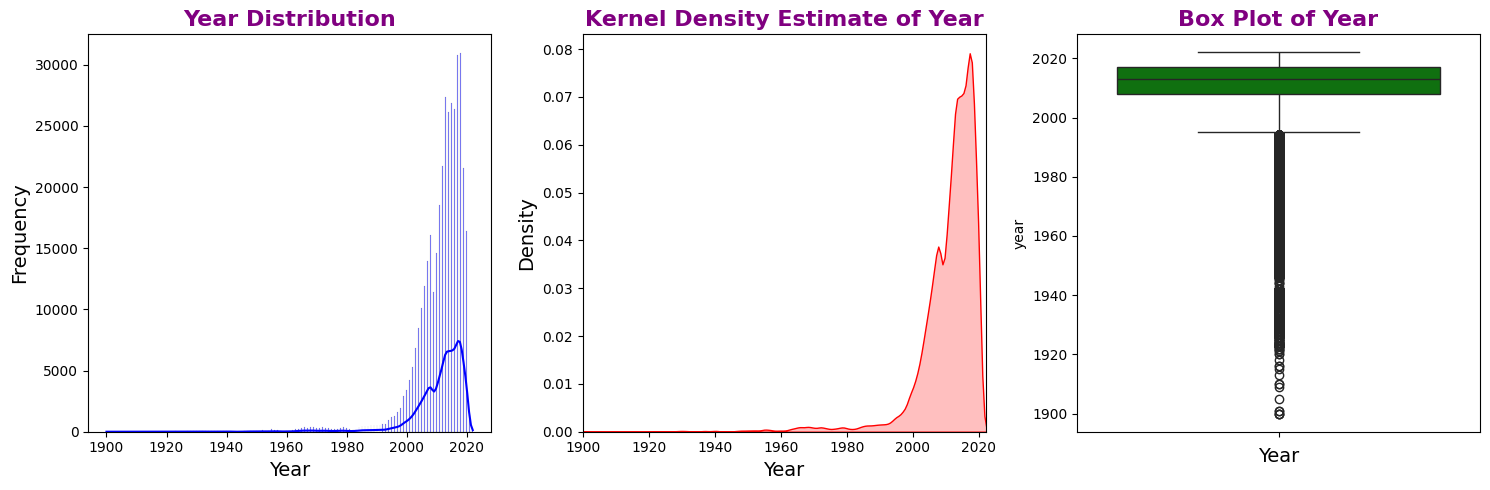

In [67]:
plot_hist_kde_box('year', filter_df)

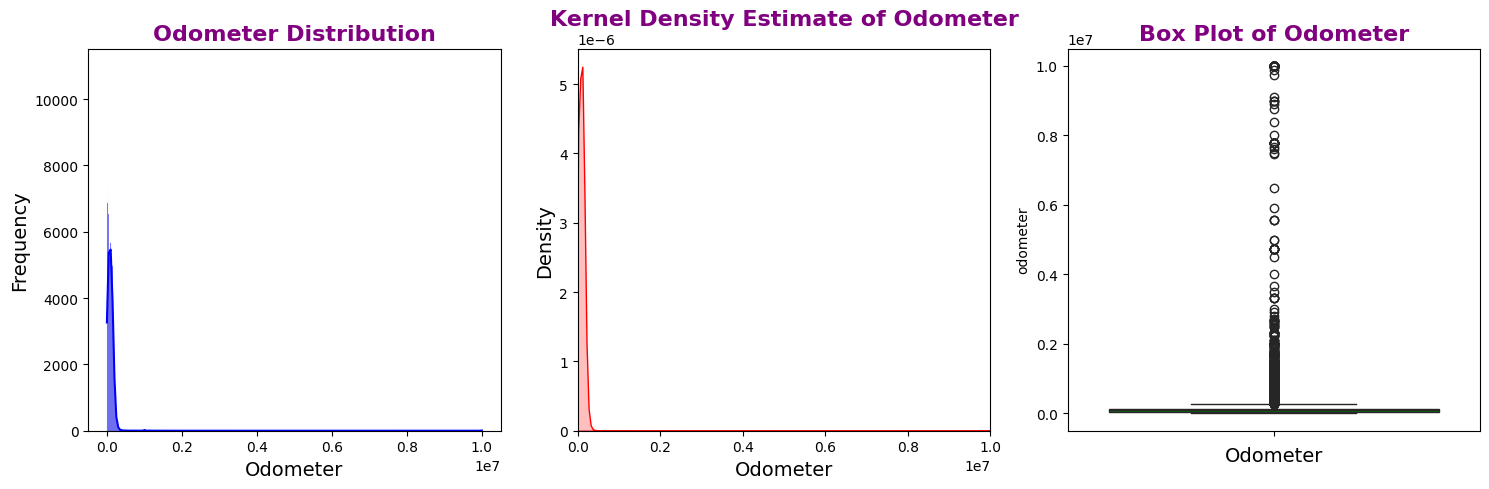

In [68]:
plot_hist_kde_box('odometer', filter_df)

In [69]:
def plot_pie_count(column_name, data=df):
    plt.figure(figsize=(15, 5))

    # Pie Plot
    plt.subplot(1, 2, 1)
    data[column_name].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.ylabel('')

    # Count Plot
    plt.subplot(1, 2, 2)
    sns.countplot(x=column_name, data=data, palette='viridis')
    plt.title(f'Count of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(column_name.capitalize(), fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.tight_layout()
    plt.show()

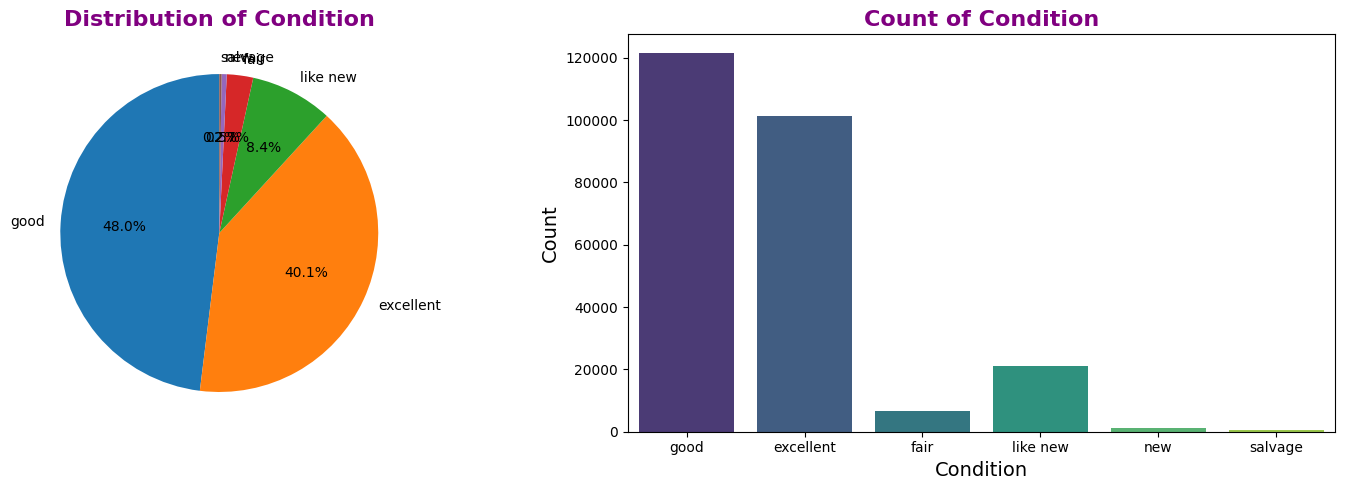

In [70]:
plot_pie_count('condition')

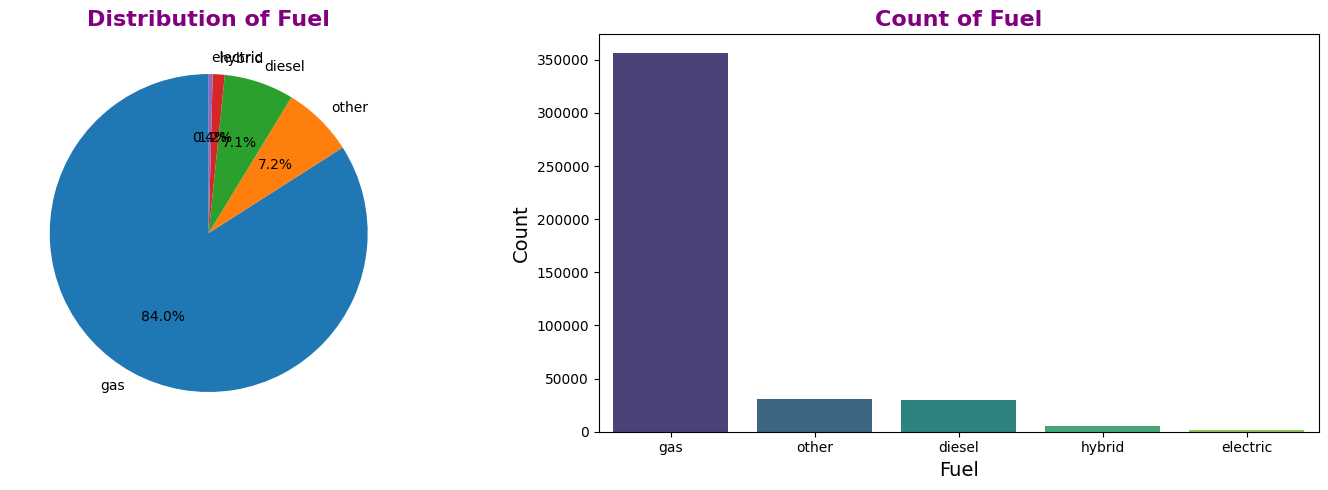

In [71]:
plot_pie_count('fuel')

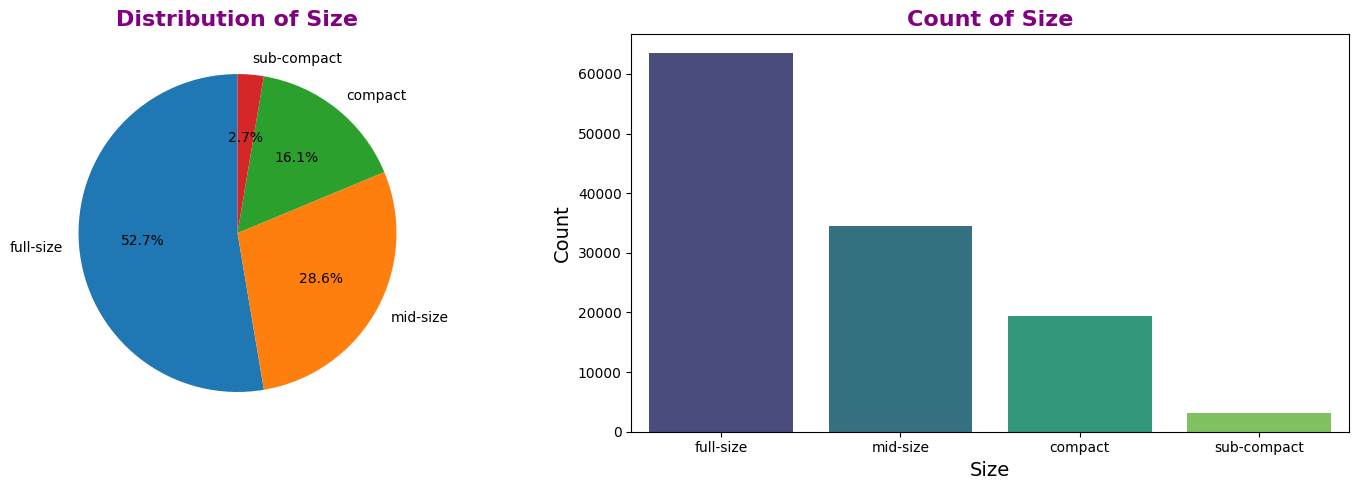

In [72]:
plot_pie_count('size')

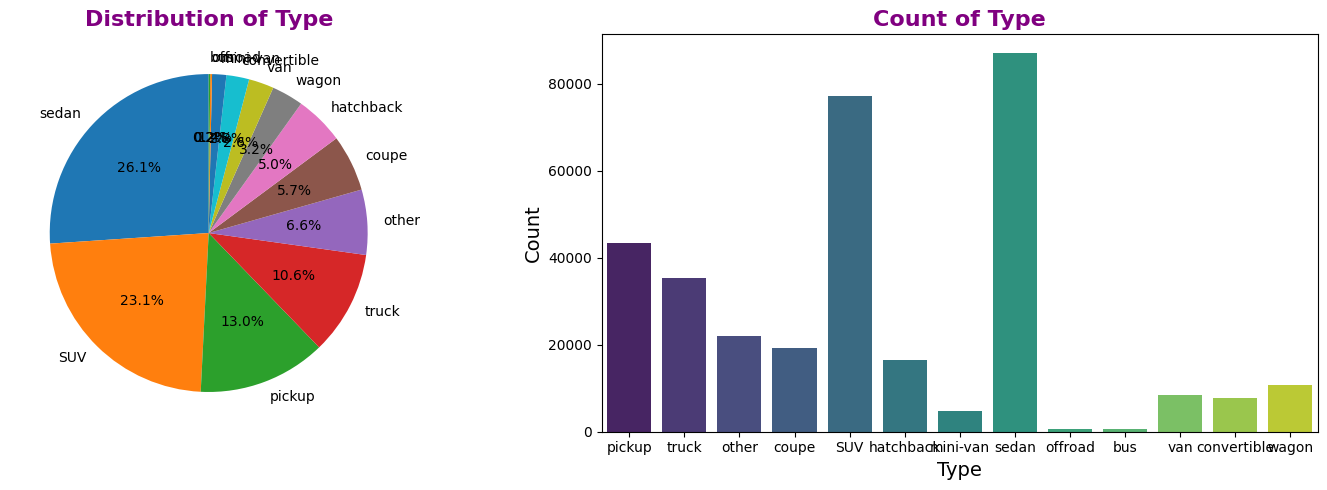

In [73]:
plot_pie_count('type')

In [74]:
category_columns = ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']

for col in category_columns:
  print(df[col].value_counts())
  print(f"Number of unique values in {col}: {df[col].nunique()}")
  print(f'\n')

region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64
Number of unique values in region: 404


manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               542

### Best feature encoding for categorical columns

Ordinal Encoding = ['condition', 'cylinders', 'size']

One Hot Encoding = ['fuel', 'transmission', 'drive', 'type', 'paint_color']

Target Encoding = ['model', 'manufacturer', 'region', 'state']

## Preprocessing

In [75]:
# Columns to remove
columns_to_remove = ['id', 'url', 'region_url', 'title_status', 'VIN', 'image_url', 'description', 'county', 'posting_date']
if set(columns_to_remove).issubset(df.columns):
  df.drop(columns=columns_to_remove, axis=1, inplace=True)

In [76]:
lower_bound = df['price'].quantile(.10)
upper_bound = df['price'].quantile(.99)
df_clean = df[(df['price'] > lower_bound) & (df['price'] < upper_bound)]

In [77]:
print(f"Original dataset size: {len(df)}")
print(f"Filtered train size: {len(df_clean)}")
print(f"Removed samples from train: {len(df) - len(df_clean)}")
print(f"Removed samples from total data: {(len(df) - len(df_clean)) / len(df) * 100:.2f}%")

Original dataset size: 426880
Filtered train size: 379462
Removed samples from train: 47418
Removed samples from total data: 11.11%


In [92]:
df_clean['price'].describe()

,price
count,379462.000000
mean,18655.889947
std,13276.815366
min,501.000000
25%,7795.000000
50%,15595.000000
75%,27590.000000
max,66992.000000


In [78]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (303569, 16)
Shape of X_test: (75893, 16)


In [95]:
num_features = X_train.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

ordinal_cols = ['condition', 'cylinders', 'size']
onehot_cols = ['fuel', 'transmission', 'drive', 'type', 'paint_color']
target_cols = ['model', 'manufacturer', 'region', 'state']

ordianl_categories = [
    ['salvage', 'fair', 'good', 'excellent', 'like new', 'new'],
    ['other', '3 cylinders', '4 cylinders', '5 cylinders', '6 cylinders', '8 cylinders', '10 cylinders', '12 cylinders'],
    ['sub-compact', 'compact', 'mid-size', 'full-size'],
]

ord_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal_encoder', OrdinalEncoder(categories=ordianl_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

hot_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))

])

tar_transforemr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder( handle_unknown='value',
        handle_missing='value',
        return_df=False ))
])

num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('ordinal_encoder', ord_transformer, ordinal_cols),
    ('onehot_encoder', hot_transformer, onehot_cols),
    ('target_encoder', tar_transforemr, target_cols),
    ('num_transformer', num_transformer, num_features)
])

In [97]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [100]:
model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42
    )

In [101]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [102]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2) Score: {r2 * 100:.2f}")

In [103]:
y_train_pred = model.predict(X_train)

In [104]:
evaluate_model(y_train, y_train_pred, 'XGBoost (Result of train set)')

Model: XGBoost (Result of train set)
Mean Squared Error (MSE): 21009786.00
Root Mean Squared Error (RMSE): 4583.64
Mean Absolute Error (MAE): 2939.23
R-squared (R2) Score: 88.09


In [105]:
y_test_pred = model.predict(X_test)

In [106]:
evaluate_model(y_test, y_test_pred, 'XGBoost (Result of test set)')

Model: XGBoost (Result of test set)
Mean Squared Error (MSE): 25645168.00
Root Mean Squared Error (RMSE): 5064.11
Mean Absolute Error (MAE): 3172.37
R-squared (R2) Score: 85.42


## Fine Tuning the Model

In [108]:
xgbregressor = XGBRegressor(n_jobs=-1, verbose=3, random_state=42)

params = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    # 'subsample': [0.8, 1.0],
    # 'colsample_bytree': [0.8, 1.0],
    # 'gamma': [0, 0.1, 0.2],
    # 'reg_alpha': [0, 0.1, 0.2],
    # 'reg_lambda': [0, 0.1, 0.2],
    'random_state': [42]
}

grid_search = GridSearchCV(
    estimator=xgbregressor,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [200, 400],
                         'random_state': [42]},
             scoring='neg_mean_squared_error', verbose=3)

In [109]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Model:", best_model)
print("Best Parameters:", best_params)
print("Best Score (MSE):", best_score)

Best Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 400, 'random_state': 42}
Best Score (MSE): -16253824.8


In [112]:
y_train_tund_pred = best_model.predict(X_train)

In [110]:
y_test_tund_pred = best_model.predict(X_test)

In [113]:
evaluate_model(y_train, y_train_tund_pred, 'XGBoost (Result of Train Tuned)')

Model: XGBoost (Result of Train Tuned)
Mean Squared Error (MSE): 11068100.00
Root Mean Squared Error (RMSE): 3326.88
Mean Absolute Error (MAE): 2157.20
R-squared (R2) Score: 93.72


In [115]:
evaluate_model(y_test, y_test_tund_pred, 'XGBoost (Result of Test Tuned)')

Model: XGBoost (Result of Test Tuned)
Mean Squared Error (MSE): 18453760.00
Root Mean Squared Error (RMSE): 4295.78
Mean Absolute Error (MAE): 2602.48
R-squared (R2) Score: 89.51


## Saving the model

In [117]:
# Just for first time!
joblib.dump(best_model, 'xgb_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

# Load the model and preprocessor
# best_model = joblib.load('xgb_model.pkl')
# preprocessor = joblib.load('preprocessor.pkl')

## Project Report: Used Cars Price Prediction

This report summarizes the steps taken to build a model for predicting used car prices based on the provided dataset.

### 1. Data Loading and Initial Exploration

- **Action:** Loaded the dataset from Kaggle Hub.
- **Evidence:** Displayed the head and tail of the dataframe (`df.head()`, `df.tail()`). Checked the shape of the dataset (`df.shape`). Displayed column names (`df.columns`).
- **Result:** The dataset was successfully loaded and basic information about its structure and contents was obtained.

### 2. Exploratory Data Analysis (EDA)

- **Action:** Examined data types, missing values, and summary statistics. Visualized missing values using a heatmap. Analyzed correlations between numerical features. Plotted distributions of key numerical features (`price`, `year`, `odometer`) and categorical features (`condition`, `fuel`, `size`, `type`) after handling outliers in 'price'. Investigated the unique values and counts for all categorical columns.
- **Evidence:**
    - Data types and non-null counts: `df.info()`
    - Missing values count: `df.isnull().sum()`
    - Total missing values: `df.isnull().sum().sum()`
    - Missing values heatmap: `sns.heatmap(df.isnull()...)`
    - Correlation matrix: `df.select_dtypes(include=['number']).corr()` and heatmap.
    - Distribution plots: `plot_hist_kde_box()` for numerical features.
    - Pie and count plots: `plot_pie_count()` for categorical features.
    - Unique value counts for categorical columns: Loop through `category_columns` and print `value_counts()` and `nunique()`.
- **Result:** Identified columns with a high percentage of missing values, observed the distribution of numerical and categorical features, and identified potential outliers in the 'price' column.

### 3. Preprocessing

- **Action:** Removed irrelevant columns (`id`, `url`, `region_url`, `title_status`, `VIN`, `image_url`, `description`, `county`, `posting_date`). Handled outliers in the 'price' column by filtering the data. Split the data into training and testing sets. Defined preprocessing pipelines for numerical and categorical features using appropriate encoding strategies (Ordinal, One-Hot, Target Encoding) and imputation techniques (SimpleImputer, KNNImputer, RobustScaler). Applied the preprocessing steps to the training and testing data.
- **Evidence:**
    - Column removal: `df.drop(columns=columns_to_remove, axis=1, inplace=True)`
    - Outlier handling: Filtering using quantiles and displaying size before and after filtering.
    - Train/test split: `train_test_split(X, y, test_size=0.2, random_state=42)`. Checked shapes of the split datasets.
    - Preprocessing pipelines: Defined `ord_transformer`, `hot_transformer`, `tar_transforemr`, `num_transformer`, and `preprocessor`.
    - Applied preprocessing: `preprocessor.fit_transform(X_train, y_train)` and `preprocessor.transform(X_test)`.

### 4. Model Training and Evaluation (Initial)

- **Action:** Trained an initial XGBoost Regressor model on the preprocessed training data. Evaluated the model's performance on both the training and testing sets using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score.
- **Evidence:**
    - Model initialization: `model = XGBRegressor(...)`
    - Model training: `model.fit(X_train, y_train)`
    - Evaluation on training set: `evaluate_model(y_train, y_train_pred, 'XGBoost (Result of train set)')`
    - Evaluation on testing set: `evaluate_model(y_test, y_test_pred, 'XGBoost (Result of test set)')`
- **Result:** The initial model showed good performance, with an R2 score of 88.09% on the training set and 85.42% on the testing set.

### 5. Fine-Tuning the Model

- **Action:** Performed a GridSearchCV to find the best hyperparameters for the XGBoost Regressor model. The parameters tuned included `n_estimators`, `max_depth`, and `learning_rate`.
- **Evidence:**
    - GridSearchCV setup: `grid_search = GridSearchCV(...)`
    - GridSearchCV fitting: `grid_search.fit(X_train, y_train)`
    - Best parameters and score: `grid_search.best_estimator_`, `grid_search.best_params_`, `grid_search.best_score_`
- **Result:** The best parameters found were `{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 400, 'random_state': 42}`. The best cross-validation score (negative MSE) was -16253824.8.

### 6. Model Evaluation (Tuned)

- **Action:** Evaluated the best model found through GridSearchCV on both the training and testing sets using the same metrics as before.
- **Evidence:**
    - Evaluation on tuned training set: `evaluate_model(y_train, y_train_tund_pred, 'XGBoost (Result of Train Tuned)')`
    - Evaluation on tuned testing set: `evaluate_model(y_test, y_test_tund_pred, 'XGBoost (Result of Test Tuned)')`
- **Result:** The fine-tuned model showed improved performance, with an R2 score of 93.72% on the training set and 89.51% on the testing set. This indicates that the fine-tuning process helped to optimize the model's performance.

### 7. Saving the Model

- **Action:** Saved the best performing model and the preprocessor using `joblib`.
- **Evidence:** `joblib.dump(best_model, 'xgb_model.pkl')` and `joblib.dump(preprocessor, 'preprocessor.pkl')`
- **Result:** The trained model and preprocessor were successfully saved for future use.